# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Step 1: Load the Dataset
 
## Load the dataset (assuming you downloaded it from Kaggle and renamed it to boston.csv)

In [2]:
df = pd.read_csv('boston.csv')  # replace with the actual path if needed

In [4]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

In [7]:
df.duplicated().sum()

0

## Separate Features and Target

In [8]:
x = df.drop("medv", axis=1)
y = df['medv']

## Train Test Split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

## LR Model

In [10]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

## Predict

In [11]:
y_pred = lr.predict(x_test)

In [12]:
y_pred

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

## Evaluation

In [20]:
r2 = r2_score(y_test, y_pred)

In [21]:
print(f"R2 Score: {r2:.2f}")

R2 Score: 0.67


## Visualization

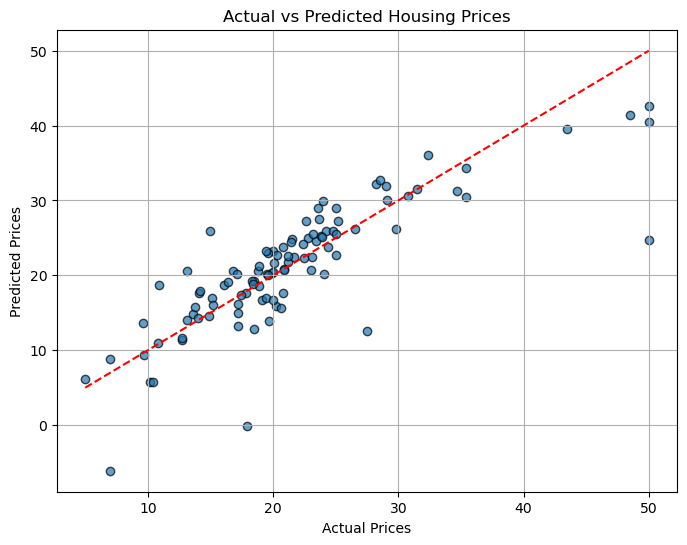

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.grid(True)
plt.show()

In [18]:
def predict_medv():
    print("Enter the following values:")

    crim = float(input("CRIM (Per capita crime rate by town): "))
    zn = float(input("ZN (Proportion of residential land zoned for large lots): "))
    indus = float(input("INDUS (Proportion of non-retail business acres per town): "))
    chas = int(input("CHAS (1 if tract bounds river, 0 otherwise): "))
    nox = float(input("NOX (Nitric oxides concentration): "))
    rm = float(input("RM (Average number of rooms per dwelling): "))
    age = float(input("AGE (% owner-occupied units built before 1940): "))
    dis = float(input("DIS (Distance to employment centers): "))
    rad = int(input("RAD (Index of accessibility to radial highways): "))
    tax = float(input("TAX (Property tax rate per $10,000): "))
    ptratio = float(input("PTRATIO (Pupil-teacher ratio): "))
    b = float(input("B (1000(Bk - 0.63)^2): "))
    lstat = float(input("LSTAT (% lower status population): "))

    # Create a single-row DataFrame with input values
    input_data = pd.DataFrame([[crim, zn, indus, chas, nox, rm, age, dis,
                                rad, tax, ptratio, b, lstat]],
                              columns=['crim', 'zn', 'indus', 'chas', 'nox', 'rm',
                                       'age', 'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat'])

    # Predict using the trained model
    prediction = lr.predict(input_data)
    print(f"\nPredicted House Price (MEDV): ${prediction[0]:.2f}")

In [19]:
predict_medv()

Enter the following values:
CRIM (Per capita crime rate by town): 0.00632
ZN (Proportion of residential land zoned for large lots): 18.0
INDUS (Proportion of non-retail business acres per town): 2.31
CHAS (1 if tract bounds river, 0 otherwise): 0
NOX (Nitric oxides concentration): 0.538
RM (Average number of rooms per dwelling): 6.575
AGE (% owner-occupied units built before 1940): 65.2
DIS (Distance to employment centers): 4.0900
RAD (Index of accessibility to radial highways): 1
TAX (Property tax rate per $10,000): 296
PTRATIO (Pupil-teacher ratio): 15.3
B (1000(Bk - 0.63)^2): 396.90
LSTAT (% lower status population): 4.98

Predicted House Price (MEDV): $29.95
